# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [14]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray


In [15]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
master_file.head()

/var/folders/qt/gw51rl910mz34lqwqrn9v7v80000gn/T/ipykernel_33436/2361419187.py:2: DtypeWarning: Columns (0: OR_SOLO_FE_sig_DATASET ALL, 1: Neutral_masked_DATASET ALL, 2: (WHO guidance before cat ver1) Miotto et al. (PMID 29284687), WHO NGS Guide 2018_Source of additional grading evidence, 3: (WHO guidance before cat ver1) RIF CC guide 2021_Source of additional grading evidence, 4: Selection evidence_Source of additional grading evidence, 5: (WHO guidance before cat ver1) WHO_endorsed_assay_Source of additional grading evidence, 6: Comment, 7: Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983), 8: Footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [127]:
#variants_excel = pd.read_excel("WHO-UCN-TB-2023.7-eng.xlsx", skiprows=2)

# Let's take a look at the data
# variants_excel.head()

# removed to only look at the full dataset first

In [16]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


### 2) Data Cleaning and Ordinal Encoding

In [17]:
# look at the columns of the master file and filter relevant rows
#print(master_file.columns)

master_file_clean = master_file.dropna(subset=["mutation", "drug", "FINAL CONFIDENCE GRADING"])

# standardize the strings
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip() # may need further data cleaning for "?" characters
master_file_clean["drug"] = master_file_clean["drug"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim'": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])
#print(master_file_clean)

# keep only necessary columns
model_df = master_file_clean[[
    "mutation",
    "gene",
    "drug",
    "FINAL CONFIDENCE GRADING",
    "grade_ordinal"
]].copy()

model_df.head()

print(model_df["drug"].unique())


<ArrowStringArray>
['4) Not assoc w R - Interim',           '5) Not assoc w R',
  '3) Uncertain significance',     '2) Assoc w R - Interim',
               '1) Assoc w R']
Length: 5, dtype: str
<ArrowStringArray>
[    'Amikacin',  'Bedaquiline',  'Capreomycin',  'Clofazimine',
    'Delamanid',   'Ethambutol',  'Ethionamide',    'Isoniazid',
    'Kanamycin', 'Levofloxacin',    'Linezolid', 'Moxifloxacin',
 'Pyrazinamide',   'Rifampicin', 'Streptomycin']
Length: 15, dtype: str


In [18]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((2048, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = model_df.merge(TB_drugs, on="drug", how="left")
print(final_data.head())

    mutation  gene      drug   FINAL CONFIDENCE GRADING  grade_ordinal  \
0  c.1044G>A  bacA  Amikacin           5) Not assoc w R            0.0   
1   c.-18T>C  bacA  Amikacin  3) Uncertain significance            2.0   
2   c.-21G>A  bacA  Amikacin  3) Uncertain significance            2.0   
3   c.-32G>A  bacA  Amikacin  3) Uncertain significance            2.0   
4   c.-32G>T  bacA  Amikacin  3) Uncertain significance            2.0   

                                              smiles  \
0  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
1  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
2  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
3  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   
4  C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...   

                                         fingerprint  
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ... 

In [19]:
final_data_copy = final_data.dropna(subset=["fingerprint"]).copy()
final_data_copy.head()


,mutation,gene,drug,FINAL CONFIDENCE GRADING,grade_ordinal,smiles,fingerprint
0,c.1044G>A,bacA,Amikacin,5) Not assoc w R,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,c.-18T>C,bacA,Amikacin,3) Uncertain significance,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,c.-21G>A,bacA,Amikacin,3) Uncertain significance,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,c.-32G>A,bacA,Amikacin,3) Uncertain significance,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,c.-32G>T,bacA,Amikacin,3) Uncertain significance,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [23]:
# Ordinal encoding for Mutation, Gene, and Drug
final_ml_copy = final_data_copy.copy()
final_ml_copy["mutation"] = final_ml_copy["mutation"].astype("category").cat.codes
final_ml_copy["gene"] = final_ml_copy["gene"].astype("category").cat.codes
final_ml_copy["drug"] = final_ml_copy["drug"].astype("category").cat.codes
final_ml_copy["smiles"] = final_ml_copy["smiles"].astype("category").cat.codes

final_ml_copy.head()


,mutation,gene,drug,FINAL CONFIDENCE GRADING,grade_ordinal,smiles,fingerprint
0,2682,17,0,5) Not assoc w R,0.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,772,17,0,3) Uncertain significance,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,960,17,0,3) Uncertain significance,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1350,17,0,3) Uncertain significance,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1351,17,0,3) Uncertain significance,2.0,3,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


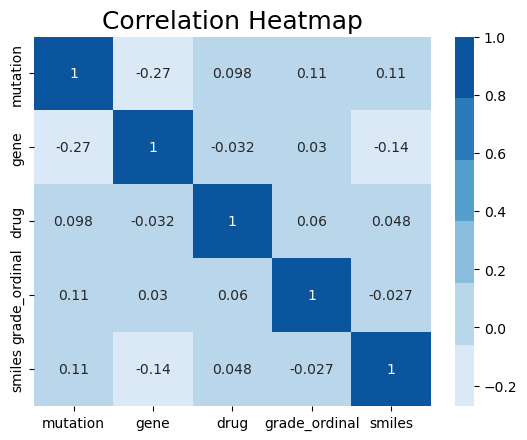

In [29]:
data_copy = final_ml_copy.copy()

X = data_copy.drop(columns=['FINAL CONFIDENCE GRADING','fingerprint'])


sns.heatmap(X.corr(), annot=True, cmap = sns.color_palette("Blues"))
plt.title('Correlation Heatmap', fontsize = 18)
plt.show()

In [25]:
import umap.umap_ as umap

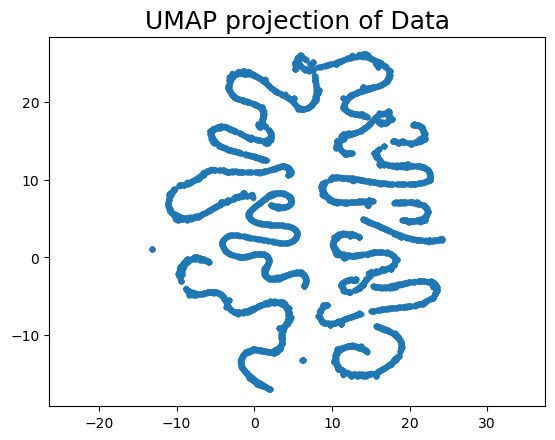

In [28]:
newX = umap.UMAP().fit_transform(X)

plt.scatter(newX[:, 0], newX[:, 1], marker = '.', alpha = 0.3)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Data', fontsize = 18)
plt.show()

In [20]:
final_data_df = pd.DataFrame(final_data_copy["fingerprint"].tolist(), index=final_data_copy.index)
final_data_df.columns = [f"fp_{i}" for i in range(final_data_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([final_data.drop(columns=["fingerprint"]), final_data_df], axis=1)
print(final_ml.shape)
final_ml.head()

KeyboardInterrupt: 

In [133]:
# check distribution of grades
print(final_ml["grade_ordinal"].value_counts().sort_index())
print(final_ml["grade_ordinal"].value_counts(normalize=True).sort_index()) # most of the grades are 2...Uncertain significance

grade_ordinal
0.0      473
2.0    33002
3.0     1119
4.0      244
Name: count, dtype: int64
grade_ordinal
0.0    0.013577
2.0    0.947299
3.0    0.032120
4.0    0.007004
Name: proportion, dtype: float64


# Add visualizations HERE
## PCA, Umap etc - Sidney

### 3) Build a baseline model

In [134]:
# take a subset of the data to only look at gene, drug, and WHO grade for resistance
baseline_data = final_ml[["gene", "drug", "grade_ordinal"]].copy()
print(baseline_data.head())

x_base = baseline_data[["gene", "drug"]]
y_base = baseline_data["grade_ordinal"]

X_encoded = pd.get_dummies(x_base, columns=["gene", "drug"]) # change to one hot encoding 

# split training and test data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_encoded, y_base, test_size=0.2, random_state=42, stratify=y_base)


   gene      drug  grade_ordinal
0  bacA  Amikacin            0.0
1  bacA  Amikacin            2.0
2  bacA  Amikacin            2.0
3  bacA  Amikacin            2.0
4  bacA  Amikacin            2.0


              precision    recall  f1-score   support

         0.0       0.02      0.63      0.05        94
         2.0       0.99      0.46      0.63      6601
         3.0       0.19      0.69      0.30       224
         4.0       0.06      0.78      0.11        49

    accuracy                           0.48      6968
   macro avg       0.32      0.64      0.27      6968
weighted avg       0.95      0.48      0.61      6968

Accuracy: 0.48


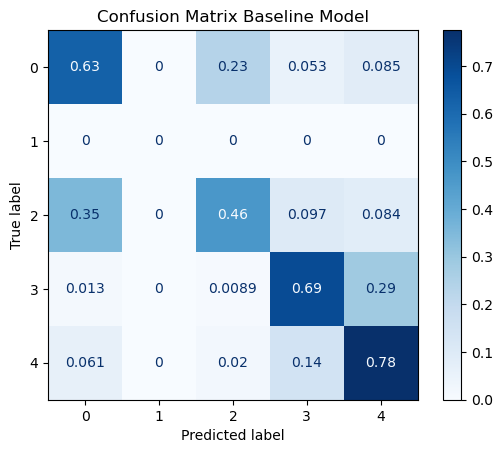

In [135]:
# Fit a baseline logistic regression model, balance the data for each class
baseline_model = LogisticRegression(max_iter=2000, class_weight="balanced")
baseline_model.fit(Xb_train, yb_train)

# predict resistance class
y_pred = baseline_model.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()

### 4) Test with mutation data - instead of genes, let's look at mutations

              precision    recall  f1-score   support

         0.0       0.36      0.34      0.35        94
         2.0       0.97      0.89      0.93      6601
         3.0       0.20      0.42      0.27       224
         4.0       0.09      0.69      0.16        49

    accuracy                           0.87      6968
   macro avg       0.41      0.59      0.43      6968
weighted avg       0.93      0.87      0.89      6968

Accuracy: 0.87


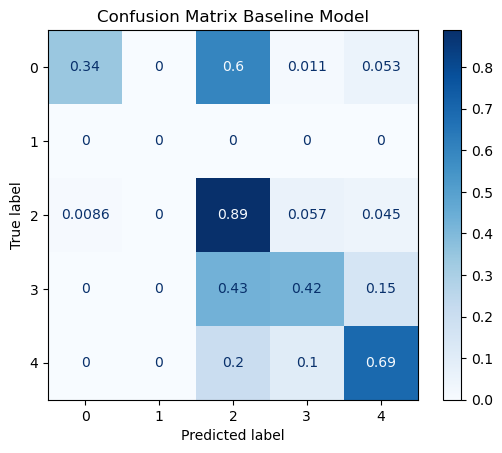

In [141]:
# test another baseline logistic regression model to look at mutation data and drug resistance 
mutation_baseline = final_ml[["mutation", "drug", "grade_ordinal"]].dropna().copy()

x_base = mutation_baseline[["mutation", "drug"]]
y_base = mutation_baseline["grade_ordinal"]

# split test and training data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(x_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

# Use sparse one hot encoding for genetic mutations
preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), ["mutation", "drug"])])
mutation_model = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))])

# fit the model
mutation_model.fit(Xb_train, yb_train)

# predict the resistance labels
y_pred = mutation_model.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()


In [139]:
# Limit data to only top mutations 
print(final_ml["mutation"].nunique())
print(final_ml["mutation"].value_counts().head(10))


19553
mutation
LoF            15
deletion       14
p.Met1?        14
p.Ala11Val     11
c.-5G>A        10
c.-34C>T       10
c.-81G>A       10
p.Ala134Val    10
p.Ala89Glu      9
p.Thr24Ala      9
Name: count, dtype: int64


In [ ]:
with tarfile.open('card-data.tar.bz2') as tar:
    tar.extractall(path="./extracted_files")
    

#tree, svm, naive bais
# test hiding some drugs with similar structures
structurally similar pairs
# Amikacin and Kanamycin
# Levofloxacin and Moxifloxacin
# Isoniazid and Ethionamide

# bring in supplemental data from the Card database